In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
# Momentum With Batch Gradient Decent 
class MovmentunWithBGD:
    def __init__(self,lr=0.01,beta=0.9,epochs=2000):
        self.eta=lr
        self.beta=beta
        self.epochs=epochs
        self.losses=[]

        self.w=None
        self.b=0.0

        self.v_w=None
        self.v_b=0.0

    def fit(self,x_trian,y_train):
        m,n=x_train.shape

        self.w=np.zeros(n)
        self.b=0.0

        self.v_w=np.zeros(n)
        self.v_b=0.0

        for epoch in range(self.epochs):
            pred=x_train@self.w+self.b

            error=pred-y_train

            dw=(1/m)*(x_train.T@error)
            db=np.mean(error)


            self.v_w=(self.beta * self.v_w) + (self.eta * dw)
            self.v_b=(self.beta * self.v_b) + (self.eta * db)

            self.w-=self.v_w
            self.b-=self.v_b

            loss=np.mean(error**2)/2
            self.losses.append(loss)

            if epoch %100==0:
                print(f"Epoch : {epoch} | Loss {loss}")

        return self.w,self.b

    def predict(self,x):
        pred=x@self.w + self.b
        return pred

    def get_losses(self):
        return self.losses
    
    

In [5]:
df=pd.read_csv('data.csv')

In [6]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [7]:
df.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [8]:
data=df.drop(['area_type', 'availability', 'location', 'size', 'society','total_sqft'],axis=1)
data.head()
       

,bath,balcony,price
0,2.0,1.0,39.07
1,5.0,3.0,120.00
2,2.0,3.0,62.00
3,3.0,1.0,95.00
4,2.0,1.0,51.00


In [9]:
data.dropna(axis=0,inplace=True)


In [10]:
data.isnull().sum()

bath       0
balcony    0
price      0
dtype: int64

In [11]:
x=data.drop('price',axis=1)
y=data['price']

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
x_train

,bath,balcony
7087,4.0,1.0
9422,2.0,2.0
2770,4.0,2.0
12230,6.0,2.0
7914,2.0,2.0
...,...,...
12533,2.0,1.0
5465,2.0,1.0
5675,2.0,1.0
903,3.0,2.0


In [14]:
len(x_train),len(x_test),len(y_train),len(y_test)

(10168, 2543, 10168, 2543)

In [15]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10168 entries, 7087 to 7647
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   bath     10168 non-null  float64
 1   balcony  10168 non-null  float64
dtypes: float64(2)
memory usage: 238.3 KB


In [16]:
x_train = np.asarray(x_train, dtype=float)
y_train = np.asarray(y_train, dtype=float).ravel()

In [17]:
x_train = x_train.astype(float)

Epoch : 0 | Loss 14187.88805401013
Epoch : 100 | Loss 14037.99374249775
Epoch : 200 | Loss 13876.894427240399
Epoch : 300 | Loss 13719.528454796236
Epoch : 400 | Loss 13565.809543874924
Epoch : 500 | Loss 13415.653026379565
Epoch : 600 | Loss 13268.976200010024
Epoch : 700 | Loss 13125.698282631518
Epoch : 800 | Loss 12985.740367692322
Epoch : 900 | Loss 12849.025380676578
Epoch : 1000 | Loss 12715.478036568169
Epoch : 1100 | Loss 12585.024798302225
Epoch : 1200 | Loss 12457.593836181279
Epoch : 1300 | Loss 12333.114988233681
Epoch : 1400 | Loss 12211.519721492463
Epoch : 1500 | Loss 12092.741094173167
Epoch : 1600 | Loss 11976.713718729858
Epoch : 1700 | Loss 11863.373725768912
Epoch : 1800 | Loss 11752.658728800627
Epoch : 1900 | Loss 11644.507789809237


(array([6.24274891, 3.17828959]), 1.867690100612777)

In [19]:
print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("w:", model.w.shape)

x_train: (10168, 2)
y_train: (10168,)
w: (2,)


In [32]:

model=MovmentunWithBGD(lr=0.001)

In [33]:
model.fit(x_train,y_train)

Epoch : 0 | Loss 14187.88805401013
Epoch : 100 | Loss 6949.155640072682
Epoch : 200 | Loss 6899.229856614414
Epoch : 300 | Loss 6882.671429095771
Epoch : 400 | Loss 6874.340189896289
Epoch : 500 | Loss 6868.7462762000405
Epoch : 600 | Loss 6864.527712726093
Epoch : 700 | Loss 6861.231980860928
Epoch : 800 | Loss 6858.632032098728
Epoch : 900 | Loss 6856.575626091162
Epoch : 1000 | Loss 6854.948004739375
Epoch : 1100 | Loss 6853.659525204982
Epoch : 1200 | Loss 6852.639472138067
Epoch : 1300 | Loss 6851.83191437874
Epoch : 1400 | Loss 6851.1925831733915
Epoch : 1500 | Loss 6850.686433917455
Epoch : 1600 | Loss 6850.285722786239
Epoch : 1700 | Loss 6849.968485491187
Epoch : 1800 | Loss 6849.717333239054
Epoch : 1900 | Loss 6849.518499574113


(array([46.31331824,  4.27854697]), -21.962521136139387)

In [34]:
pred=model.predict(x_test)

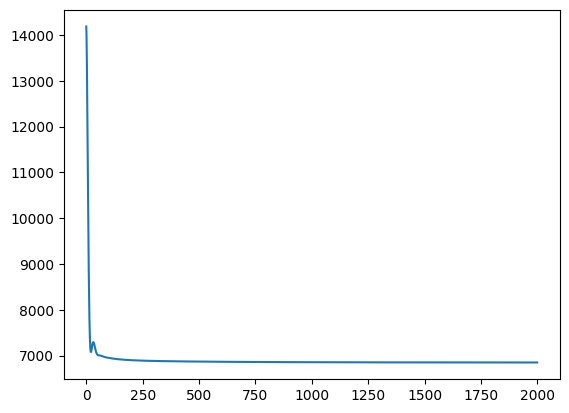

In [35]:
plt.plot(model.losses)

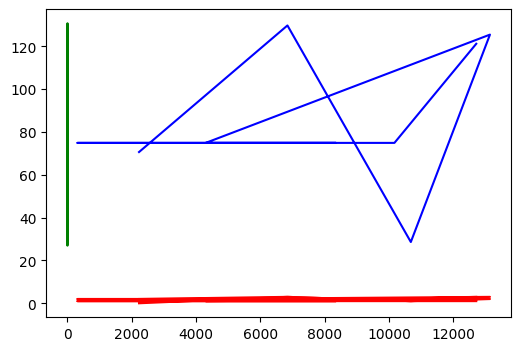

In [37]:
plt.figure(figsize=(6,4))
plt.plot(x_test[:10],c='r')
plt.plot(pred[:10],c='b')
plt.plot(pred2[:10],c='g')
plt.show()

In [70]:
# momentum with SGD
class MomentumWithSGD:
    def __init__(self,lr=0.001,beta=0.9,epochs=2000):
        self.lr=lr
        self.beta=beta
        self.epochs=epochs
        self.w=None
        self.b=0.0
        self.v_w=None
        self.v_b=0.0
        self.losses=[]


    def fit(self,x_train,y_train):
        m,n=x_train.shape
        self.w=np.zeros(n)
        self.b=0.0
        self.v_w=np.zeros(n)
        self.v_b=0.0

        for epoch in range(self.epochs):
            idx=np.random.permutation(m)

            for i in idx:
                x_i=x_train[i]
                y_i=y_train[i]

                pred=np.dot(x_i,self.w)+self.b
                
                error=pred-y_i

                dw=error*x_i
                db=error

                self.v_w=(self.beta * self.v_w) + (self.lr * dw)
                self.v_b=(self.beta * self.v_b) + (self.lr * db)

                self.w-=self.v_w
                self.b-=self.v_b

            pred = x_train @ self.w + self.b
            loss = np.mean((pred - y_train) ** 2) / 2
            self.losses.append(loss)

            if epoch % 100==0:
                print(f"Epoch : {epoch}  |  Loss :{loss} ")
                    
        return self.w,self.b

    def predict(self,x_test):
        pred=np.dot(x_test,self.w)+self.b
        return pred

    def get_losses(self):
        return self.losses
  

In [74]:
model3=MomentumWithSGD()
weigt,bais=model3.fit(x_train,y_train)

Epoch : 0  |  Loss :7262.3359206879495 
Epoch : 100  |  Loss :7613.78498889358 
Epoch : 200  |  Loss :7040.620251733505 
Epoch : 300  |  Loss :45025.50725448577 
Epoch : 400  |  Loss :8444.340207114801 
Epoch : 500  |  Loss :11299.421202221527 
Epoch : 600  |  Loss :7053.126103305041 
Epoch : 700  |  Loss :133826.2677693531 
Epoch : 800  |  Loss :7138.417820770557 
Epoch : 900  |  Loss :7099.098328560188 
Epoch : 1000  |  Loss :7338.76688923274 
Epoch : 1100  |  Loss :7234.373414981621 
Epoch : 1200  |  Loss :7040.681234794756 
Epoch : 1300  |  Loss :7409.3836131597145 
Epoch : 1400  |  Loss :8280.612458417345 
Epoch : 1500  |  Loss :7094.519626659591 
Epoch : 1600  |  Loss :7003.281514261463 
Epoch : 1700  |  Loss :6864.052321728532 
Epoch : 1800  |  Loss :9585.286308921586 
Epoch : 1900  |  Loss :7082.76557968919 


In [72]:
print(x_train.mean(axis=0))
print(x_train.std(axis=0))

[2.61949253 1.58369394]
[1.24025773 0.81445297]


In [75]:
weigt,bais

(array([59.14210381, -6.04946571]), -45.97280245388481)

In [77]:
model4=LinearRegression()
model4.fit(x_train,y_train)
model4.coef_,model4.intercept_

(array([46.84809322,  5.1053981 ]), -25.02675733593344)

In [84]:
# movementum with mini batch gradient decent
class MomentumMBGD:
    def __init__(self,lr=0.01,beta=0.9,batch_size=32,epochs=1000):
        self.lr=lr
        self.beta=beta
        self.batch_size=batch_size
        self.epochs=epochs

        self.w=None
        self.b=0.0

        self.v_w=None
        self.v_b=0.0

        self.losses=[]

    def fit(self,x_train,y_train):
        m,n=x_train.shape
        self.w=np.zeros(n)
        self.b=0.0
        self.v_w=np.zeros(n)
        self.v_b=0.0
        for epoch in range(self.epochs):
            idx=np.random.permutation(m)
            x_shuffled=x_train[idx]
            y_shuffled=y_train[idx]

            for i in range(0,m,self.batch_size):
                x_batch=x_shuffled[i:i+self.batch_size]
                y_batch=y_shuffled[i:i+self.batch_size]

                B=y_batch.shape[0]

                pred=np.dot(x_batch,self.w)+self.b

                error=pred-y_batch

                dw=(1/B)*np.dot(error,x_batch)
                db=(1/B)*np.sum(error)

                self.v_w=(self.beta * self.v_w) + (self.lr * dw)
                self.v_b=(self.beta * self.v_b) + (self.lr * db)

                self.w-=self.v_w
                self.b-=self.v_b

            pred1=x_train@self.w + self.b
            loss=np.mean((pred1-y_train)**2)/2
            self.losses.append(loss)

            if epoch % 100==0:
                print(f"Epoch   :{epoch}  |   Loss :{loss:.4f}")
        return self.w,self.b

    def predict(self,x_test):
        pred=x_test@self.w+self.b
        return pred

    def get_losses(self):
        return self.losses
                

In [92]:
model5=MomentumMBGD(epochs=2000)

In [93]:
w_5,b_5=model5.fit(x_train,y_train)

Epoch   :0  |   Loss :7151.6325
Epoch   :100  |   Loss :10386.4078
Epoch   :200  |   Loss :9845.2111
Epoch   :300  |   Loss :7137.7952
Epoch   :400  |   Loss :8185.3360
Epoch   :500  |   Loss :6914.0343
Epoch   :600  |   Loss :6853.0151
Epoch   :700  |   Loss :7032.2347
Epoch   :800  |   Loss :6887.1091
Epoch   :900  |   Loss :6946.9459
Epoch   :1000  |   Loss :7036.4142
Epoch   :1100  |   Loss :7394.1030
Epoch   :1200  |   Loss :8204.0772
Epoch   :1300  |   Loss :7616.1332
Epoch   :1400  |   Loss :7085.7186
Epoch   :1500  |   Loss :6933.9293
Epoch   :1600  |   Loss :8074.0829
Epoch   :1700  |   Loss :15860.8662
Epoch   :1800  |   Loss :8397.4339
Epoch   :1900  |   Loss :7388.5685


In [94]:
w_5, b_5

(array([49.61858534, -3.05386155]), -23.61972322821815)

In [89]:
ll=LinearRegression()

In [90]:
ll.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [91]:
ll.coef_,ll.intercept_

(array([46.84809322,  5.1053981 ]), -25.02675733593344)

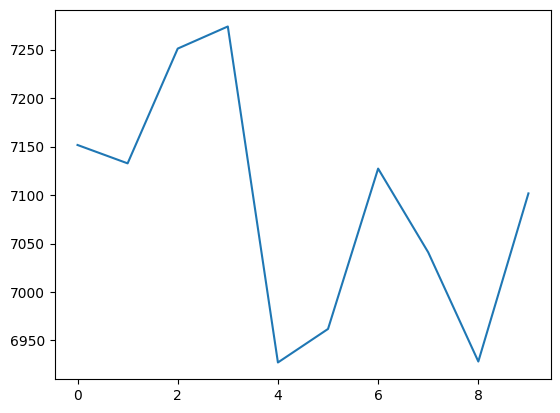

In [96]:
plt.plot(model5.get_losses()[:10])